<a href="https://colab.research.google.com/github/aydanGHusby/athlete-injury-prediction/blob/main/Athlete_Injuries_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split # divide data into training and test sets
from sklearn.linear_model import LogisticRegression #
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

In [2]:
# DataFrame is a spreadsheet (rows and coliumbs); allows computer to store and read data from a dataset

In [3]:
# load dataset from CSV file into pandas
df = pd.read_csv("collegiate_athlete_injury_dataset.csv")
# display DF
df


,Athlete_ID,Age,Gender,Height_cm,Weight_kg,Position,Training_Intensity,Training_Hours_Per_Week,Recovery_Days_Per_Week,Match_Count_Per_Week,Rest_Between_Events_Days,Fatigue_Score,Performance_Score,Team_Contribution_Score,Load_Balance_Score,ACL_Risk_Score,Injury_Indicator
0,A001,24,Female,195,99,Center,2,13,2,3,1,1,99,58,100,4,0
1,A002,21,Male,192,65,Forward,8,14,1,3,1,4,55,63,83,73,0
2,A003,22,Male,163,83,Guard,8,8,2,1,3,6,58,62,100,62,0
3,A004,24,Female,192,90,Guard,1,13,1,1,1,7,82,74,78,51,0
4,A005,20,Female,173,79,Center,3,9,1,2,1,2,90,51,83,49,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,A196,23,Female,169,88,Guard,3,11,3,4,1,3,77,94,100,39,0
196,A197,21,Male,185,95,Forward,8,5,3,4,2,5,56,61,100,56,0
197,A198,19,Female,193,89,Center,5,6,2,1,1,5,81,81,100,25,0
198,A199,19,Male,166,55,Center,9,7,2,3,1,9,60,81,97,61,0


# Different Ways of Accessing Data

In [4]:
# display first 10 rows of data
df.head(10)

,Athlete_ID,Age,Gender,Height_cm,Weight_kg,Position,Training_Intensity,Training_Hours_Per_Week,Recovery_Days_Per_Week,Match_Count_Per_Week,Rest_Between_Events_Days,Fatigue_Score,Performance_Score,Team_Contribution_Score,Load_Balance_Score,ACL_Risk_Score,Injury_Indicator
0,A001,24,Female,195,99,Center,2,13,2,3,1,1,99,58,100,4,0
1,A002,21,Male,192,65,Forward,8,14,1,3,1,4,55,63,83,73,0
2,A003,22,Male,163,83,Guard,8,8,2,1,3,6,58,62,100,62,0
3,A004,24,Female,192,90,Guard,1,13,1,1,1,7,82,74,78,51,0
4,A005,20,Female,173,79,Center,3,9,1,2,1,2,90,51,83,49,0
5,A006,22,Female,180,75,Guard,9,14,3,4,1,6,74,84,99,54,0
6,A007,22,Female,179,90,Forward,5,13,1,4,2,7,97,56,78,84,1
7,A008,24,Female,167,64,Center,6,7,2,3,3,2,62,70,100,42,0
8,A009,19,Female,166,91,Guard,4,19,2,3,3,2,58,67,80,50,0
9,A010,20,Female,162,63,Center,2,8,3,3,2,7,62,52,100,35,0


In [5]:
# display random list of 10 rows of data
df.sample(10)

,Athlete_ID,Age,Gender,Height_cm,Weight_kg,Position,Training_Intensity,Training_Hours_Per_Week,Recovery_Days_Per_Week,Match_Count_Per_Week,Rest_Between_Events_Days,Fatigue_Score,Performance_Score,Team_Contribution_Score,Load_Balance_Score,ACL_Risk_Score,Injury_Indicator
123,A124,18,Female,160,99,Guard,6,13,2,2,2,8,53,58,97,54,0
131,A132,20,Male,185,90,Center,4,12,2,2,3,5,59,55,100,47,0
164,A165,24,Male,183,81,Center,8,9,3,2,2,7,75,84,100,60,0
151,A152,23,Female,182,66,Center,8,5,2,1,2,1,71,63,100,18,0
75,A076,20,Male,160,94,Center,8,7,2,1,3,2,86,96,100,22,0
105,A106,22,Female,172,57,Center,7,11,2,1,3,1,63,88,100,41,0
109,A110,22,Male,178,74,Guard,1,11,2,2,2,3,76,61,95,28,0
42,A043,24,Male,192,68,Forward,9,6,1,2,3,7,74,51,100,49,0
39,A040,24,Female,188,63,Guard,8,10,2,2,3,8,70,53,91,77,0
86,A087,21,Male,182,99,Forward,3,6,1,3,2,1,93,52,100,23,0


In [6]:
# display last 10 rows of data
df.tail(10)

,Athlete_ID,Age,Gender,Height_cm,Weight_kg,Position,Training_Intensity,Training_Hours_Per_Week,Recovery_Days_Per_Week,Match_Count_Per_Week,Rest_Between_Events_Days,Fatigue_Score,Performance_Score,Team_Contribution_Score,Load_Balance_Score,ACL_Risk_Score,Injury_Indicator
190,A191,21,Female,176,79,Guard,7,14,1,1,2,8,71,83,74,94,1
191,A192,22,Female,185,76,Guard,9,18,1,2,2,9,97,53,79,79,1
192,A193,24,Female,167,81,Forward,1,12,2,4,1,4,86,74,94,30,0
193,A194,20,Female,188,67,Center,6,15,2,3,2,1,64,64,95,40,0
194,A195,20,Female,185,87,Guard,7,18,2,4,2,1,84,53,87,42,0
195,A196,23,Female,169,88,Guard,3,11,3,4,1,3,77,94,100,39,0
196,A197,21,Male,185,95,Forward,8,5,3,4,2,5,56,61,100,56,0
197,A198,19,Female,193,89,Center,5,6,2,1,1,5,81,81,100,25,0
198,A199,19,Male,166,55,Center,9,7,2,3,1,9,60,81,97,61,0
199,A200,22,Male,163,75,Forward,5,5,2,3,1,2,59,77,100,23,0


In [7]:
# get the Athlete ID of athlete 100
df['Athlete_ID'].get(100)

'A101'

# Learn About Our Data

In [8]:
# gives info about what each column is
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Athlete_ID                200 non-null    object
 1   Age                       200 non-null    int64 
 2   Gender                    200 non-null    object
 3   Height_cm                 200 non-null    int64 
 4   Weight_kg                 200 non-null    int64 
 5   Position                  200 non-null    object
 6   Training_Intensity        200 non-null    int64 
 7   Training_Hours_Per_Week   200 non-null    int64 
 8   Recovery_Days_Per_Week    200 non-null    int64 
 9   Match_Count_Per_Week      200 non-null    int64 
 10  Rest_Between_Events_Days  200 non-null    int64 
 11  Fatigue_Score             200 non-null    int64 
 12  Performance_Score         200 non-null    int64 
 13  Team_Contribution_Score   200 non-null    int64 
 14  Load_Balance_Score        

In [9]:
# Generate descriptive statistics of numerical columns in the dataframe
df.describe()

,Age,Height_cm,Weight_kg,Training_Intensity,Training_Hours_Per_Week,Recovery_Days_Per_Week,Match_Count_Per_Week,Rest_Between_Events_Days,Fatigue_Score,Performance_Score,Team_Contribution_Score,Load_Balance_Score,ACL_Risk_Score,Injury_Indicator
count,200.000000,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,21.170000,180.805000,77.475000,5.10500,11.315000,1.985000,2.385000,1.975000,4.920000,74.465000,72.630000,93.395000,46.470000,0.070000
std,2.002787,11.529598,12.440789,2.49904,4.438952,0.811212,1.154748,0.817137,2.560543,14.636939,14.432762,8.660485,18.943956,0.255787
min,18.000000,160.000000,55.000000,1.00000,5.000000,1.000000,1.000000,1.000000,1.000000,50.000000,50.000000,62.000000,2.000000,0.000000
25%,19.000000,171.000000,67.000000,3.00000,7.000000,1.000000,1.000000,1.000000,3.000000,62.000000,60.750000,89.000000,33.000000,0.000000
50%,21.000000,182.500000,77.500000,5.00000,11.000000,2.000000,2.000000,2.000000,5.000000,74.000000,72.000000,98.000000,45.000000,0.000000
75%,23.000000,191.000000,89.000000,7.00000,15.000000,3.000000,3.000000,3.000000,7.000000,86.250000,85.000000,100.000000,60.000000,0.000000
max,24.000000,199.000000,99.000000,9.00000,19.000000,3.000000,4.000000,3.000000,9.000000,99.000000,99.000000,100.000000,100.000000,1.000000


# Cleaning up Data

In [10]:
# real data has gaps
# a missing value shows up as NAN (Not A Number); this is an empty cell
# check for number of missing values:
df.isnull().sum()

,0
Athlete_ID,0
Age,0
Gender,0
Height_cm,0
Weight_kg,0
Position,0
Training_Intensity,0
Training_Hours_Per_Week,0
Recovery_Days_Per_Week,0
Match_Count_Per_Week,0


In [11]:
# If there are rows with more than 0, remove rows with missing values (if theres a few):
df.dropna()


,Athlete_ID,Age,Gender,Height_cm,Weight_kg,Position,Training_Intensity,Training_Hours_Per_Week,Recovery_Days_Per_Week,Match_Count_Per_Week,Rest_Between_Events_Days,Fatigue_Score,Performance_Score,Team_Contribution_Score,Load_Balance_Score,ACL_Risk_Score,Injury_Indicator
0,A001,24,Female,195,99,Center,2,13,2,3,1,1,99,58,100,4,0
1,A002,21,Male,192,65,Forward,8,14,1,3,1,4,55,63,83,73,0
2,A003,22,Male,163,83,Guard,8,8,2,1,3,6,58,62,100,62,0
3,A004,24,Female,192,90,Guard,1,13,1,1,1,7,82,74,78,51,0
4,A005,20,Female,173,79,Center,3,9,1,2,1,2,90,51,83,49,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,A196,23,Female,169,88,Guard,3,11,3,4,1,3,77,94,100,39,0
196,A197,21,Male,185,95,Forward,8,5,3,4,2,5,56,61,100,56,0
197,A198,19,Female,193,89,Center,5,6,2,1,1,5,81,81,100,25,0
198,A199,19,Male,166,55,Center,9,7,2,3,1,9,60,81,97,61,0


In [12]:
# if there are MANY missing values:
for col in df.columns:
  if df[col].isnull().any():
    median_val = df[col].median()
    df[col] = df[col]

# Visualizing the Data

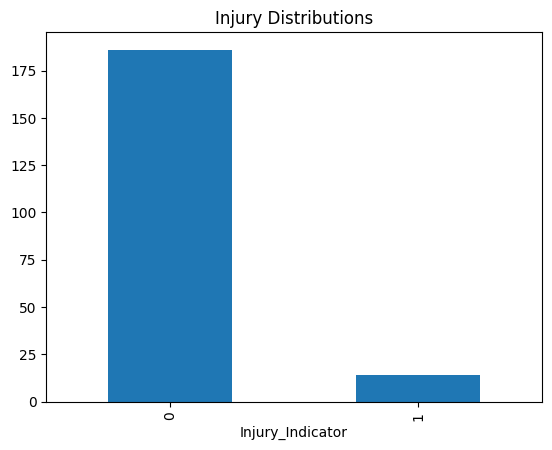

In [13]:
# count occurrences of ech unique value in Injury_indicator column and plot it in bar chart
df["Injury_Indicator"].value_counts().plot(kind="bar")

# set title of plot
plt.title("Injury Distributions")

# display plot (1 = ACL injury, 0 = no ACL injury)
plt.show()

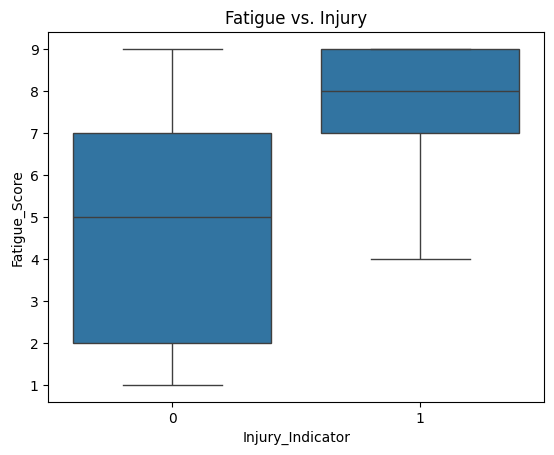

In [14]:
# compare fatigue score vs injury indicator
sns.boxplot(x="Injury_Indicator", y="Fatigue_Score", data=df)

# set title
plt.title("Fatigue vs. Injury")

# display plot
plt.show()

#Correlation - how things move together:
## positive - both go up at the same time
## negative - as one goes up, the other goes down
## zero - there is no correlation

# Correlation heatmap - visual map of relationships between variables
## closer to readm stronger positive rcorrelation; closer to blue, stronger negative correlation


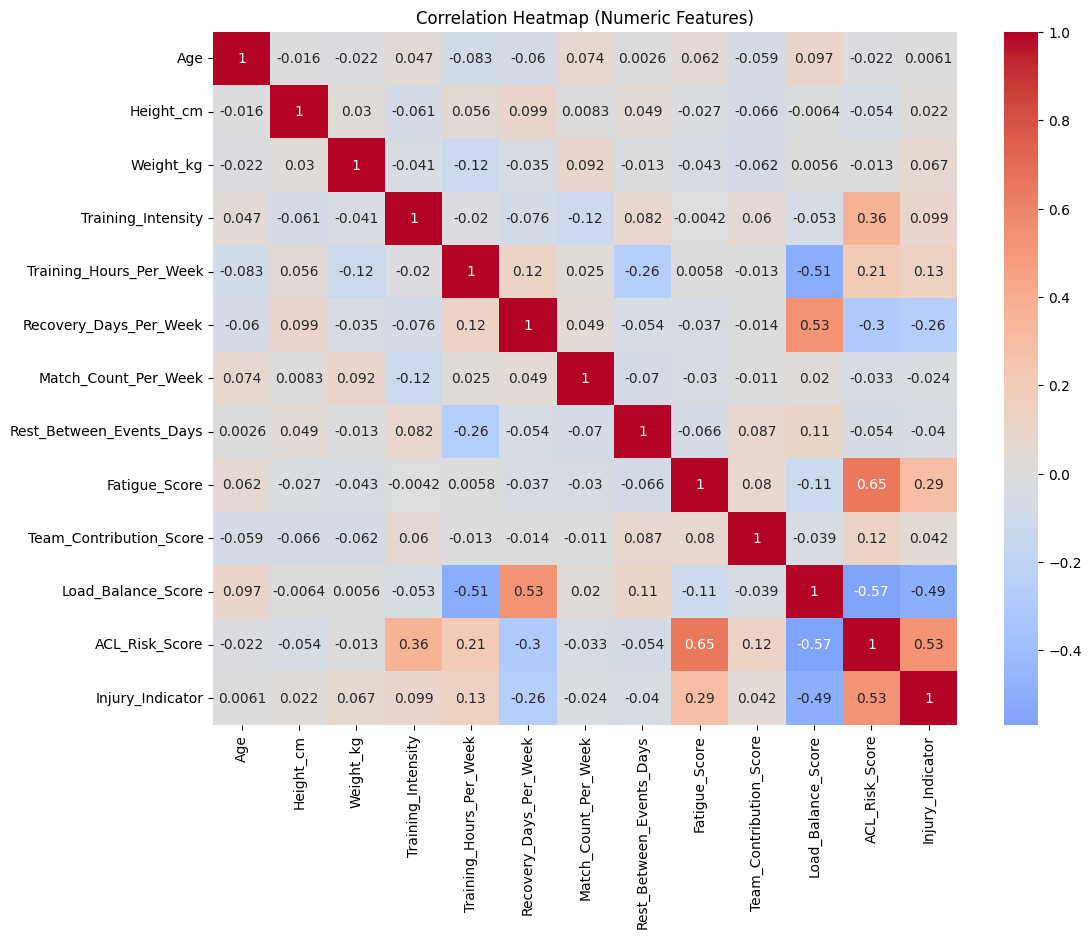

In [15]:
# Select only numeric columns
num_cols = ["Age", "Height_cm", "Weight_kg",
            "Training_Intensity",
            "Training_Hours_Per_Week",
            "Recovery_Days_Per_Week",
            "Match_Count_Per_Week",
            "Rest_Between_Events_Days",
            "Fatigue_Score",
            "Performance-Score",
            "Team_Contribution_Score",
            "Load_Balance_Score",
            "ACL_Risk_Score",
            "Injury_Indicator"]
# filter num_cols to ensure only existing cols are included
num_cols = [c for c in num_cols if c in df.columns]

# calculate correlation matriz for selected numeric cols
corr = df[num_cols].corr()

# plot the correlation heatmap
plt.figure(figsize=(12,9))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

In [16]:
# problem with raw data: model can't take in text (because it is a different tool with different rules)
# convert problems into numbers
# numerical vs. categorical:
  # numerical - can average it; numbers
  # categorical - can ONLY name it; cannot perform math on it; names, genders, etc



# Drop Useless Columns

In [17]:
df.drop(['Athlete_ID'], axis=1, inplace=True)
df.head()

,Age,Gender,Height_cm,Weight_kg,Position,Training_Intensity,Training_Hours_Per_Week,Recovery_Days_Per_Week,Match_Count_Per_Week,Rest_Between_Events_Days,Fatigue_Score,Performance_Score,Team_Contribution_Score,Load_Balance_Score,ACL_Risk_Score,Injury_Indicator
0,24,Female,195,99,Center,2,13,2,3,1,1,99,58,100,4,0
1,21,Male,192,65,Forward,8,14,1,3,1,4,55,63,83,73,0
2,22,Male,163,83,Guard,8,8,2,1,3,6,58,62,100,62,0
3,24,Female,192,90,Guard,1,13,1,1,1,7,82,74,78,51,0
4,20,Female,173,79,Center,3,9,1,2,1,2,90,51,83,49,0


# Turning Words into Numbers

In [18]:
# want everything to be treated eaqually, so don't just assign numbers
# create columns for each position (i.e. forward, center, etc.); have a "checkbox" (1 for matching 0 for not)


In [19]:
# Encoding (get_dummies creates 0/1 categories; 1 = true, 0 = false):
df_encoded = pd.get_dummies(df, columns=['Gender', 'Position'], drop_first=True)
df_encoded.head()

,Age,Height_cm,Weight_kg,Training_Intensity,Training_Hours_Per_Week,Recovery_Days_Per_Week,Match_Count_Per_Week,Rest_Between_Events_Days,Fatigue_Score,Performance_Score,Team_Contribution_Score,Load_Balance_Score,ACL_Risk_Score,Injury_Indicator,Gender_Male,Position_Forward,Position_Guard
0,24,195,99,2,13,2,3,1,1,99,58,100,4,0,False,False,False
1,21,192,65,8,14,1,3,1,4,55,63,83,73,0,True,True,False
2,22,163,83,8,8,2,1,3,6,58,62,100,62,0,True,False,True
3,24,192,90,1,13,1,1,1,7,82,74,78,51,0,False,False,True
4,20,173,79,3,9,1,2,1,2,90,51,83,49,0,False,False,False


# Convert to X and y

In [20]:
# capitalize Xs, but lowercase ys in ML
# all shown except injury_indicator; the features
X = df_encoded.drop("Injury_Indicator", axis=1) # axis=1 means drop along columns instead of rows
# ONLY injusry_indicator shown; the target (what we want to predict)
y = df_encoded["Injury_Indicator"]
X.head()

,Age,Height_cm,Weight_kg,Training_Intensity,Training_Hours_Per_Week,Recovery_Days_Per_Week,Match_Count_Per_Week,Rest_Between_Events_Days,Fatigue_Score,Performance_Score,Team_Contribution_Score,Load_Balance_Score,ACL_Risk_Score,Gender_Male,Position_Forward,Position_Guard
0,24,195,99,2,13,2,3,1,1,99,58,100,4,False,False,False
1,21,192,65,8,14,1,3,1,4,55,63,83,73,True,True,False
2,22,163,83,8,8,2,1,3,6,58,62,100,62,True,False,True
3,24,192,90,1,13,1,1,1,7,82,74,78,51,False,False,True
4,20,173,79,3,9,1,2,1,2,90,51,83,49,False,False,False


# Scaling Problem

In [21]:
# bigger numbers are NOT more important, but model takes it like that
# different ranges (i.e. age: 19-23, ACL_Risk: 45-82; takes ACL_Risk as more important)
# StandardScalar - transform mean to 0 and spread to 1 (standardizes data)

scaler = StandardScaler()

numerical_cols = ['Age', 'Height_cm',
'Weight_kg',
'Training_Intensity',
'Training_Hours_Per_Week',
'Recovery_Days_Per_Week',
'Match_Count_Per_Week',
'Rest_Between_Events_Days',
'Fatigue_Score',
'Performance_Score',
'Team_Contribution_Score',
'Load_Balance_Score',
'ACL_Risk_Score']

X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

X.head()

,Age,Height_cm,Weight_kg,Training_Intensity,Training_Hours_Per_Week,Recovery_Days_Per_Week,Match_Count_Per_Week,Rest_Between_Events_Days,Fatigue_Score,Performance_Score,Team_Contribution_Score,Load_Balance_Score,ACL_Risk_Score,Gender_Male,Position_Forward,Position_Guard
0,1.416577,1.234269,1.734537,-1.245595,0.380547,0.018537,0.533920,-1.196184,-1.534767,1.680445,-1.016210,0.764573,-2.247502,False,False,False
1,-0.085095,0.973416,-1.005266,1.161352,0.606390,-1.217279,0.533920,-1.196184,-0.360200,-1.333192,-0.668906,-1.203291,1.403961,True,True,False
2,0.415462,-1.548162,0.445218,1.161352,-0.748672,0.018537,-1.202406,1.257527,0.422844,-1.127717,-0.738367,0.764573,0.821844,True,False,True
3,1.416577,0.973416,1.009295,-1.646753,0.380547,-1.217279,-1.202406,-1.196184,0.814366,0.516085,0.095161,-1.782075,0.239726,False,False,True
4,-0.585652,-0.678652,0.122888,-0.844437,-0.522828,-1.217279,-0.334243,-1.196184,-1.143245,1.064019,-1.502434,-1.203291,0.133887,False,False,False


# Correlations

In [22]:
correlations = df_encoded.corr()["Injury_Indicator"].sort_values(ascending=False)
correlations

,Injury_Indicator
Injury_Indicator,1.000000
ACL_Risk_Score,0.525180
Fatigue_Score,0.292475
Training_Hours_Per_Week,0.130958
Training_Intensity,0.098502
Weight_kg,0.066876
Position_Guard,0.063855
Team_Contribution_Score,0.042442
Performance_Score,0.023475
Height_cm,0.021691


# Finalizing Dataset

In [23]:
# ".copy()" just creates a copy of the data (like copying a docs)
# ".shape" gives the dimension of the array
X_final = X.copy()
y_final = y.copy()

print("Final feature shape:", X_final.shape)
print("Target shape:", y_final.shape)

Final feature shape: (200, 16)
Target shape: (200,)


# Model

In [24]:
# a model is for patterb recognition
# model.fit - feed model data
# we don't test on what we study; need train/test split (model ONLY sees train set when training)
  # we will do 80/20 (train/test)

In [25]:
# split data
X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y_final,
    test_size=0.2,
    random_state=42,
    stratify=y_final
)

X_train.head()


,Age,Height_cm,Weight_kg,Training_Intensity,Training_Hours_Per_Week,Recovery_Days_Per_Week,Match_Count_Per_Week,Rest_Between_Events_Days,Fatigue_Score,Performance_Score,Team_Contribution_Score,Load_Balance_Score,ACL_Risk_Score,Gender_Male,Position_Forward,Position_Guard
43,0.916020,-0.069996,0.606383,-1.245595,-0.522828,-1.217279,-0.334243,0.030671,-0.751723,0.516085,-1.294052,-0.045724,-0.554070,False,True,False
179,-0.085095,-1.809014,-1.085849,0.359036,0.380547,0.018537,-1.202406,-1.196184,0.422844,0.516085,-0.529985,0.533060,-0.183632,False,False,True
128,-0.585652,0.625612,-0.199442,1.161352,-1.426203,1.254354,-1.202406,-1.196184,1.597410,-1.264700,0.164622,0.764573,1.351041,True,True,False
13,0.415462,0.016955,1.009295,1.562510,-0.296984,-1.217279,-0.334243,-1.196184,0.422844,-1.470175,1.762217,-0.740264,1.351041,False,True,False
173,-0.085095,1.147318,0.928713,-0.042122,1.058078,1.254354,-1.202406,1.257527,0.031322,-1.059225,0.650847,0.764573,-0.342391,False,True,False


In [26]:
# linear regression - y=mx + b; can't use for probability because it gives raw values like 42

In [27]:
# logistic regression = takes linear regression and passes through sigmoid which takes any number and squishes it between 0 and 1

In [28]:
# decision tree - comes up with many quesitons to come up with a solution by itself
  # math is really hard

# Logistic Regression Model

In [29]:
log_model = LogisticRegression(
    class_weight='balanced',
    C=0.001
)
log_model.fit(X_train, y_train)

LogisticRegression(C=0.001, class_weight='balanced')

In [30]:
X_test

,Age,Height_cm,Weight_kg,Training_Intensity,Training_Hours_Per_Week,Recovery_Days_Per_Week,Match_Count_Per_Week,Rest_Between_Events_Days,Fatigue_Score,Performance_Score,Team_Contribution_Score,Load_Balance_Score,ACL_Risk_Score,Gender_Male,Position_Forward,Position_Guard
50,0.415462,0.799514,-0.199442,-0.844437,-0.748672,-1.217279,0.533920,1.257527,1.205888,0.036643,-1.085670,-0.161481,-0.024872,False,False,False
138,-1.586766,-1.461211,-0.682936,0.760194,0.832234,-1.217279,0.533920,1.257527,-1.143245,1.132511,1.275993,-1.666318,0.768924,True,False,False
65,0.415462,1.495121,-1.005266,0.760194,0.154703,1.254354,-0.334243,0.030671,1.205888,-1.607159,-0.043760,0.764573,0.716004,True,False,False
186,0.415462,0.799514,0.686965,-0.042122,-0.296984,0.018537,1.402084,-1.196184,-1.534767,0.584577,-0.738367,-0.277237,-0.130712,True,True,False
107,-1.086209,-0.243897,-0.844101,-0.844437,1.058078,1.254354,0.533920,1.257527,1.597410,1.543461,0.650847,0.764573,0.610165,False,False,True
111,-1.586766,0.364759,-1.247014,-1.646753,0.154703,1.254354,-1.202406,-1.196184,0.031322,1.474970,0.720307,0.764573,-1.771224,False,False,False
21,0.916020,1.060367,-0.924684,-0.443279,0.832234,-1.217279,1.402084,1.257527,1.205888,0.584577,0.998150,-2.476615,1.298121,True,False,True
199,0.415462,-1.548162,-0.199442,-0.042122,-1.426203,0.018537,0.533920,-1.196184,-1.143245,-1.059225,0.303543,0.764573,-1.242027,True,True,False
89,1.416577,0.016955,-0.521771,1.161352,-0.974516,-1.217279,-0.334243,0.030671,-0.360200,-0.305816,1.484375,0.764573,-0.289471,True,True,False
76,0.916020,-1.200358,1.492790,0.359036,-1.200359,-1.217279,0.533920,-1.196184,-0.360200,-0.716766,-0.529985,0.764573,-1.136187,False,True,False


In [31]:
log_preds = log_model.predict(X_test)
log_preds # 0 - safe; 1 - injured; sigmoid run on athletes its never seen; each output compared to 0.5 5 become a 0 or 1

array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1])

# Decision Tree

In [32]:
# train the model
tree_model = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [33]:
# test the model (.predict); leaf gives prediction
tree_preds = tree_model.predict(X_test)
tree_preds

array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# Accuracy

In [34]:
# Accuracy of logistic regression
print("Logistic Accuracy:", accuracy_score(y_test, log_preds))

Logistic Accuracy: 0.875


In [35]:
# accuracy for tree
print("Tree Accuracy:", accuracy_score(y_test, log_preds))

Tree Accuracy: 0.875


# Precision and Recall

In [36]:
# accuracy alone is not everything; better way to measure
# not all mistakes are equal; some are costly
# 2 better qustions than accuracy:
  # precision - out of all that were flagged, how many are actually injured
  # recall - out of all that are injured, how many were caught

In [37]:
# precision and recall
print("Logistic Precision:", precision_score(y_test, log_preds))

print("Logistic Recall:",    recall_score(y_test, log_preds))

print("Tree Precision:",     precision_score(y_test, tree_preds))

print("Tree Recall:",        recall_score(y_test, tree_preds))

Logistic Precision: 0.3333333333333333
Logistic Recall: 0.6666666666666666
Tree Precision: 0.0
Tree Recall: 0.0


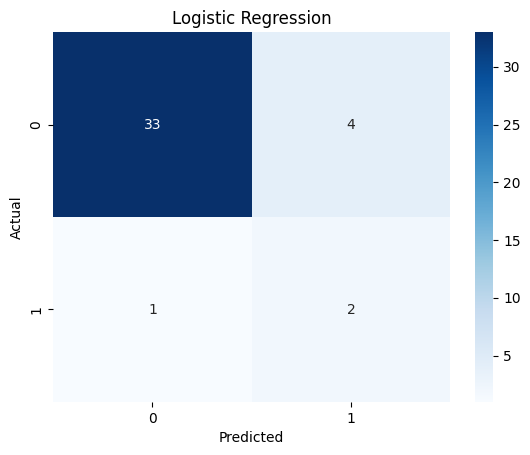

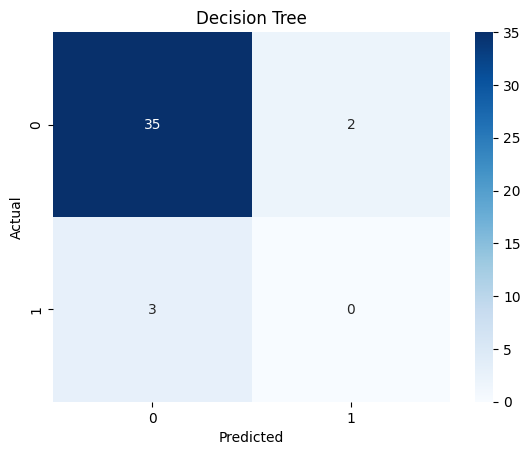

In [38]:
# anything along diagonal is correct (i.e. (0, 0), (1, 1))
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True,
                fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_confusion_matrix(y_test, log_preds,
                      "Logistic Regression")

plot_confusion_matrix(y_test, tree_preds,
                      "Decision Tree")

# What was learned by model

In [39]:
# not all features are equal; som ehave more weight
# logistic weight:
importance_log = pd.Series(
    log_model.coef_[0],
    index=X_train.columns
)

importance_log.sort_values(ascending=False)

,0
ACL_Risk_Score,0.073732
Fatigue_Score,0.038111
Training_Intensity,0.017630
Training_Hours_Per_Week,0.017123
Weight_kg,0.012127
Height_cm,0.009868
Position_Guard,0.003988
Team_Contribution_Score,0.003710
Age,-0.000966
Position_Forward,-0.002124


In [40]:
# tree weight
importance_tree = pd.Series(
    tree_model.feature_importances_,
    index=X_train.columns
)

importance_tree.sort_values(ascending=False)

,0
ACL_Risk_Score,9.223297e-01
Height_cm,3.794567e-02
Team_Contribution_Score,3.650470e-02
Load_Balance_Score,3.219908e-03
Position_Guard,3.633457e-16
Age,3.353023e-17
Weight_kg,0.000000e+00
Training_Intensity,0.000000e+00
Rest_Between_Events_Days,0.000000e+00
Match_Count_Per_Week,0.000000e+00


In [41]:
# 2 models, 2 different explanations
  # logistic regression - weight spread across many features; uses full sigmoid formula
  # decision tree - bets 92% on one column (ACL risk score)

# more models

In [42]:
# 2 more models
  # Support Vector Machines (SVM) - finds widest possible boundary between injured and safe groups
  # K_Nearest Neighbors (KNN) - predicts based on what other members do (only based on neighbors)
# same intrests, different math

# Support Vector Machines

# Overfitting Vs. Generalization

In [43]:
# want generalization (learn concept instead of memorizing)
# overfitting - memorizing answer key
# to check: training vs test accuracy; small gap means NOT overfitting (model generalizes)


In [44]:
print("Training Accuracy:", log_model.score(X_train, y_train))
print("Test Accuracy", log_model.score(X_test, y_test))

Training Accuracy: 0.90625
Test Accuracy 0.875


# Hyperparameter tuning with GridsearchCV
## C param - controls strictness in log regressin; low C = less strict
## optimize recall - missing real injury worse than false alarm
## grid search - tries all listed C values and selects best performer
## 10-fold CV - splits data 10 ways for fair score

In [47]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Base model
base_model = LogisticRegression(class_weight='balanced', max_iter=1000)

# Parameter grid to test
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100]  # Regularization strength
}

# Create GridSearchCV
grid = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=10,
    scoring="recall"  # Focus on catching injuries
)

# Fit on scaled training data (already scaled from Week 3)
grid.fit(X_train, y_train)

# Get the best model
best_model = grid.best_estimator_

print("Best C value:", grid.best_params_)

Best C value: {'C': 0.01}


# Evaluate tuned model
## after gridsearch picks best C, look at full metric suite (look at the big picture)

Accuracy: 0.925
Precision: 0.5
Recall: 1.0
F1 Score: 0.6666666666666666


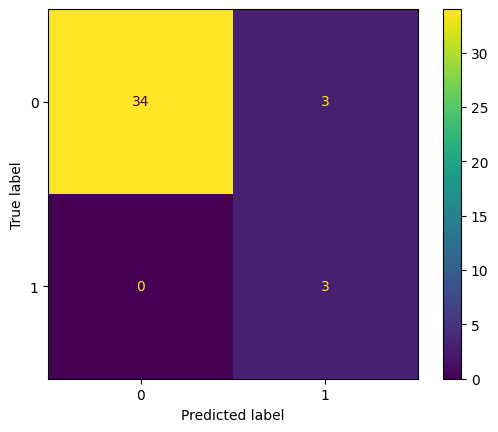

In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Predict on test set
y_pred = best_model.predict(X_test)

# Evaluate metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))

# Visualize confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# Confirm overfitting is fixed
## test training vs test accuracy

In [49]:
print("Training Accuracy:", best_model.score(X_train, y_train))
print("Test Accuracy:", best_model.score(X_test, y_test))

Training Accuracy: 0.9
Test Accuracy: 0.925


# From Probability --> Risk Level
## categorize numbers to:
### low risk when < 0.33
### medium risk when 0.33 < but < 0.66
### high risk when > 0.66

In [51]:
# Get predicted probabilities of injury
probs = best_model.predict_proba(X_test)[:, 1]

# Define simple risk levels: Low (<0.33), Medium (0.33-0.66), High (>=0.66)
y_risk = [
    "Low Risk" if p < 0.33
    else ("Medium Risk" if p < 0.66 else "High Risk")
    for p in probs
]

# see first 10 predictions
list(zip(probs[:10], y_risk[:10]))

[(np.float64(0.37419111719261916), 'Medium Risk'),
 (np.float64(0.4556156619084492), 'Medium Risk'),
 (np.float64(0.34224926215926776), 'Medium Risk'),
 (np.float64(0.2593841507582856), 'Low Risk'),
 (np.float64(0.28950477116978923), 'Low Risk'),
 (np.float64(0.10807699267803025), 'Low Risk'),
 (np.float64(0.6819425670204203), 'High Risk'),
 (np.float64(0.1314258008957587), 'Low Risk'),
 (np.float64(0.2605638109220165), 'Low Risk'),
 (np.float64(0.2066091598340183), 'Low Risk')]

# Prediction Function
## input athlete stats --> output prob + risk label

In [52]:
def predict_injury_risk(model, athlete_data, training_columns, scaler, numeric_cols):
    import pandas as pd

    # Convert dict to DataFrame
    athlete_df = pd.DataFrame([athlete_data])

    # Encode categorical features
    athlete_df_encoded = pd.get_dummies(athlete_df)

    # Add missing columns
    for col in training_columns:
        if col not in athlete_df_encoded.columns:
            athlete_df_encoded[col] = 0

    # Reorder columns to match training
    athlete_df_encoded = athlete_df_encoded[training_columns]

    # Scale numeric columns
    athlete_df_encoded[numeric_cols] = scaler.transform(athlete_df_encoded[numeric_cols])

    # Predict probability
    prob = model.predict_proba(athlete_df_encoded)[:,1][0]
    risk = "Low Risk" if prob < 0.33 else ("Medium Risk" if prob < 0.66 else "High Risk")

    return prob, risk

In [59]:
# Example: Low-risk athlete
athlete1 = {
    "Age": 20,
    "Height_cm": 180,
    "Weight_kg": 75,
    "Training_Intensity": 5,
    "Training_Hours_Per_Week": 8,
    "Recovery_Days_Per_Week": 3,
    "Match_Count_Per_Week": 1,
    "Rest_Between_Events_Days": 2,
    "Fatigue_Score": 3,
    "Performance_Score": 85,
    "Team_Contribution_Score": 80,
    "Load_Balance_Score": 80,
    "ACL_Risk_Score": 50
}


# Example: High-risk athlete
athlete2 = {
    "Age": 24,
    "Height_cm": 185,
    "Weight_kg": 85,
    "Training_Intensity": 9,
    "Training_Hours_Per_Week": 18,
    "Recovery_Days_Per_Week": 1,
    "Match_Count_Per_Week": 4,
    "Rest_Between_Events_Days": 1,
    "Fatigue_Score": 9,
    "Performance_Score": 70,
    "Team_Contribution_Score": 60,
    "Load_Balance_Score": 40,
    "ACL_Risk_Score": 80
}

athlete3 = {
    "Age": 20,
    "Height_cm": 175,
    "Weight_kg": 80,
    "Training_Intensity": 3,
    "Training_Hours_Per_Week": 10,
    "Recovery_Days_Per_Week": 4,
    "Match_Count_Per_Week": 1,
    "Rest_Between_Events_Days": 3,
    "Fatigue_Score": 4,
    "Performance_Score": 85,
    "Team_Contribution_Score": 90,
    "Load_Balance_Score": 50,
    "ACL_Risk_Score": 0
}

prob, risk = predict_injury_risk(best_model, athlete1, X_train.columns, scaler, numerical_cols)
print("Probability:", prob)
print("Risk Level:", risk)

prob, risk = predict_injury_risk(best_model, athlete2, X_train.columns, scaler, numerical_cols)
print("Probability:", prob)
print("Risk Level:", risk)

prob, risk = predict_injury_risk(best_model, athlete3, X_train.columns, scaler, numerical_cols)
print("Probability", prob)
print("Risk Level:", risk)

Probability: 0.3419192976170058
Risk Level: Medium Risk
Probability: 0.9285778148498014
Risk Level: High Risk
Probability 0.32181294379052244
Risk Level: Low Risk


# Save model

In [61]:
import joblib
joblib.dump(best_model, "injury_model.pkl")

['injury_model.pkl']

# think about impact as well as recall and accuracy

# build website using model